In [54]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li, div.text_cell_render p{width:95% !important;font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
table td, th{font-size:16px;}
table{ margin-left:0 !important;   /* 왼쪽 여백 0 */}
</style>
"""))

<font size="6" color="red"><b>ch4. 머신러닝 모형 최적화</b></font>
# 1절. 변수 선택과 차원 축소
## 1-1 변수선택과 차원축소
- 종속변수에 영향을 주는 변수들을 찾아 학습에 사용할 독립변수의 수를 줄임
(어떻게 하면 score를 높일 수 있을지?)
- 과적합과 변수들 사이의 다중공선성(변수들간 강한 상관관계)을 줄일 수 있음
* 회귀계수 해석이 어려워짐. 모델 예측력이 좋아도 해석력이 떨어짐(어떤 변수가 제일 큰 요인인지 잘), p값이
나 유의성 검정이 왜곡될 수 있음
- 모형의 학습 시간을 줄일 수 있음

- 주성분분석, 상관분석, **분류모형의 feature_importance_, 예측 모형의 coef_**
- SelectKBest : 가장 높은 score에 따라 K개의 특징을 선택
## 1-2 주성분분석(PCA, Principal Component Analysis)
- 주성분분석은 변수 선택 및 차원축소 방법(기존의 모든 변수를 조합하여 새로운 변수로 만듦) 으로 널리 사용
- 주성분 분석은 상관관계가 있는 변수들을 선형결합해서 **분산이 극대화된 상관관계가 없는 새로운 변수(주성분)
들로 축약**하는 것
- 주성분 분석은 사실 선형대수학이라기보다는 선형대수학의 활용적인 측면이 강하며 영상인식, 통계 데이터분석
(주성분 찾기), 데이터 압축, 노이즈제거 등 여러 분야에 사용
- 영상처리에서 많이 활용 : 여러개의 영상 중 대표 이미지를 찾을 때 활용

In [2]:
import seaborn as sns 
from sklearn.decomposition import PCA 
iris = sns.load_dataset('iris')
iris_X, iris_y = iris.iloc[:, :-1], iris.iloc[:, -1]
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [3]:
# 다중공전성이 있는 독립변수 4개를 다중공전성 전혀 없는 새로운 독립변수 2개로 
pca = PCA(n_components=2) #n_components : 주성분 갯수 
pca.fit(iris_X)
iris_pca = pca.transform(iris_X)
iris_pca[:3] #주성분 2개

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943]])

In [4]:
import pandas as pd 
df=pd.DataFrame(iris_pca, columns=['pca1', 'pca2']).corr(method='pearson')
df.corr

<bound method DataFrame.corr of               pca1          pca2
pca1  1.000000e+00  1.407550e-15
pca2  1.407550e-15  1.000000e+00>

In [5]:
# iris_X => df
pd.concat([iris_X, df], axis=1)

,sepal_length,sepal_width,petal_length,petal_width,pca1,pca2
0,5.1,3.5,1.4,0.2,NaN,NaN
1,4.9,3.0,1.4,0.2,NaN,NaN
2,4.7,3.2,1.3,0.2,NaN,NaN
3,4.6,3.1,1.5,0.2,NaN,NaN
4,5.0,3.6,1.4,0.2,NaN,NaN
...,...,...,...,...,...,...
147,6.5,3.0,5.2,2.0,NaN,NaN
148,6.2,3.4,5.4,2.3,NaN,NaN
149,5.9,3.0,5.1,1.8,NaN,NaN
pca1,NaN,NaN,NaN,NaN,1.000000e+00,1.407550e-15


In [6]:
# 설명분산 : 각 주성분이 원 데이터 정보량을 얼마나 잘 표편하는지 : 값이 클수록 더 중요한 주성분 
pca.explained_variance_

array([4.22824171, 0.24267075])

In [7]:
pca.explained_variance_ratio_ 
# 0~1 사이의 비율로 조정된 설명분산  
# 2개의 주성분으로 전체 데이터(독립변수 4개)의 97.77% 정도 설명 

array([0.92461872, 0.05306648])

In [8]:
pca.components_ # 주 성분의 갯수: 각 주성분이 원래 특성들과 어떤 관계가 있는지의 가중치 
# pca1 = 0.36138659 * x0 -0.08452251* x1 +  0.85667061* x2 + 0.3582892* x3
# pca2 = 0.65658877* x0 + 0.73016143* x1 -0.17337266*x2 -0.07548102*x3

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

## 1-3 상관관계 확인 
- 타겟변수와상관관계가 높은 독립변수들만 선택  

In [9]:
#redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine = pd.read_csv('data/winequality-red.csv', delimiter=';')
redwine.sample()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
462,11.0,0.26,0.68,2.55,0.085,10.0,25.0,0.997,3.18,0.61,11.8,5


- cmap의 종류 : https://jrc-park.tistory.com/155
- http://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap
-http://seaborn.pydata.org/examples/many_pairwise_correlations.html

In [21]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 
plt.rcParams['figure.figsize']=(12,4)

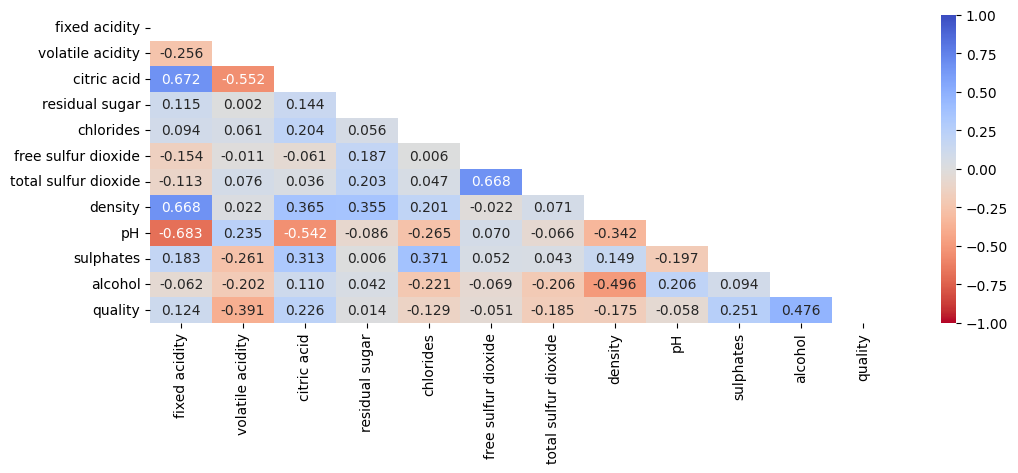

In [26]:
corr=redwine.corr(method='pearson')
#corr
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r', mask=mask)
plt.show()

In [10]:
mask=np.tril(np.ones_like(corr), k=0) # 대각선 포함 아래가 1인 삼각행렬(기본값0) 
mask=np.tril(np.ones_like(corr), k=-1) #대각선 제외 아래가 1인 삼각행렬
mask=np.triu(np.ones_like(corr), k=1) # 대각선 제외 위가 1인 삼각행렬
mask=np.triu(np.ones_like(corr), k=0) # 대각선 포함 위가 1인 삼각행렬
mask

NameError: name 'np' is not defined

## 1-4 분류모형의 feature_importance_
- 모형의 feature_importance_ 속성은 독립변수들이 종속변수에 영향을 주는 정도를 저장 
- DecisionTreeClassifier, RandomForestClassifier(tree계열), GradientBoostingClassifier, XGBclassfier, 
  LGBMclassifier, CatBoostClassifier
- LogisticRegression 이나 SVC, MLPclassifier, MultinominalNB등은 feature_importance_없음

In [17]:
X=redwine.iloc[:, :-1].to_numpy()
y=redwine.iloc[:, -1].values
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, 
                                                   stratify=y ) #층화추출
train_X.shape, train_y.shape, test_X.shape, test_y.shape, type(train_X)

((1119, 11), (1119,), (480, 11), (480,), numpy.ndarray)

In [16]:
from sklearn.ensemble import RandomForestClassifier
rf_model =RandomForestClassifier(n_estimators=10, 
                                random_state=10)
rf_model.fit(train_X, train_y)

RandomForestClassifier(n_estimators=10, random_state=10)

In [18]:
features = pd.DataFrame(np.c_[redwine.columns[:-1],
        rf_model.feature_importances_], 
                       columns=['feature', 'importance'])
features['importance'].sum()

NameError: name 'np' is not defined

In [19]:
features.sort_values(by = 'importance', ascending=False, inplace=True)
features.set_index(drop=True, keys='feature')

NameError: name 'features' is not defined

### feature_importance_를 이용한 변수 중요도 시각화 

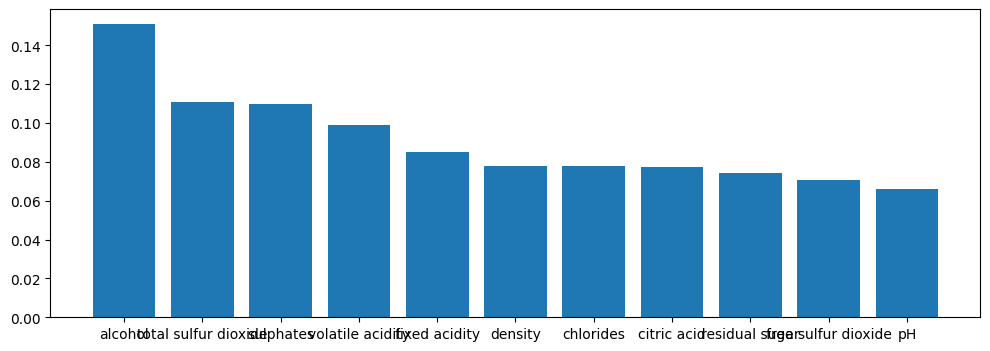

In [58]:
plt.bar(features.feature, features.importance)
plt.show()

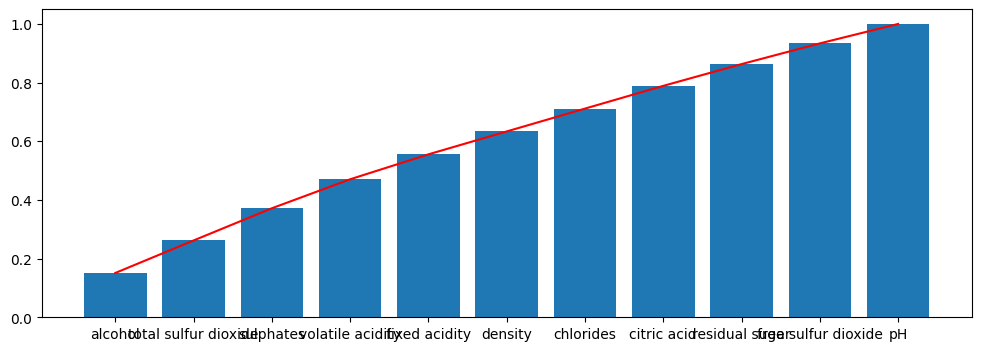

In [67]:
# 누적합을 이용한 시각화 
y_stack = np.cumsum(features.importance) # importance 누적
# y_stack
plt.bar(features.feature, y_stack)
plt.plot(features.feature, y_stack, c='r')
plt.show()

### RFE(Recursive Feature Elimination)방식 
- 중요도에 따라 낮은 변수부터 하나씩 제거해 나가면서 최종적으로 선택하고자 하는 변수의 갯수만큼 남긴다 

In [72]:
# 5개의 특징이 남을 때까지 변수를 제거 (기준:feature_importance_)
from sklearn.feature_selection import RFE
rfe_model = RFE( # RandomForestClassifier(n_estimators=10,random_state=10)
    rf_model,
    n_features_to_select=5
)
rfe_model.fit(train_X, train_y)
#rfe_model.get_support()
features_rfe = pd.DataFrame(np.c_[redwine.columns[:-1], 
                                 rfe_model.get_support()], 
                           columns=['features', 'selected'])
features_rfe.sort_values(by='selected', ascending=False)

,features,selected
1,volatile acidity,True
6,total sulfur dioxide,True
7,density,True
9,sulphates,True
10,alcohol,True
0,fixed acidity,False
2,citric acid,False
3,residual sugar,False
4,chlorides,False
5,free sulfur dioxide,False


## 1-5 SelectKBest
- 가장 높은 score에 따라 k개의 특징 변수 선택

In [22]:
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
X.shape, y.shape, type(X)

((150, 4), (150,), numpy.ndarray)

In [26]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2
X_new = SelectKBest(score_func=f_classif, #기본값
                   k=2).fit_transform(X,y) # score가 높은 독립변수 2개 추출
X_new[:3]

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2]])

In [25]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

# 2절.파라미터 탐색 
- 하이퍼파라미터(사용자가 직접 설정할 수 있는 파라미터). 어떤 파라미터를 넣는게 최적의 결과를 낼지 탐색 

    * validation_curve() :단일 하이퍼파라미터 최적화 함수(한개의 파라미터 찾아줌)
    * GridSearchCV : 그리드를 이용한 복수 하이퍼 파라미터 최적화 클래스(가장 높은 score를 내는 모형을 찾아줌) 
    
## 2-1 단일파라미터 탐색과 모형 최적화 
- validation_curve() : 최적화할 파라미터 이름과 범위, 성능 측정 기준 매개변수로 받아 파라미터의 모든 범위의 성능을 계산 

In [28]:
# 데이터 
from sklearn.datasets import load_digits
digits=load_digits()
X, y = digits.data, digits.target
images = digits.images
X.shape, y.shape, images.shape

((1797, 64), (1797,), (1797, 8, 8))

In [35]:
import numpy as np 
np.all(X[0].reshape(8,8) == images[0]) # 행렬의 모든 item에 True인지 여부 

True

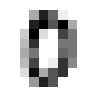

In [37]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(1,1))
plt.imshow(images[0], cmap='gray_r')
plt.axis('off')
plt.show()

In [41]:
# SVC 모델 생성
from sklearn.svm import SVC 
model = SVC(probability=True)
model.fit(X,y)

SVC(probability=True)

In [42]:
model.score(X,y)

0.996661101836394

In [45]:
h = model.predict(X[0].reshape(1,-1))[0]
prob = model.predict_proba(X[0].reshape(1,-1))[0]
model.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [51]:
print(f'에측: {h}')
for c, p in zip(model.classes_, prob):
    print(f'{c}일 확률:{p:.2%}')

에측: 0
0일 확률:99.13%
1일 확률:0.02%
2일 확률:0.05%
3일 확률:0.08%
4일 확률:0.06%
5일 확률:0.13%
6일 확률:0.07%
7일 확률:0.09%
8일 확률:0.07%
9일 확률:0.28%


In [53]:
print(model.get_params())

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [55]:
# 탐색할 gamma값의 범위 

param_range = np.linspace(0.000001,0.1,10) 
param_range = np.logspace(-6,-1,10)
param_range

array([1.00000000e-06, 3.59381366e-06, 1.29154967e-05, 4.64158883e-05,
       1.66810054e-04, 5.99484250e-04, 2.15443469e-03, 7.74263683e-03,
       2.78255940e-02, 1.00000000e-01])

In [57]:
X.shape, y.shape

((1797, 64), (1797,))

In [61]:
%%time
from sklearn.svm import SVC 
from sklearn.model_selection import validation_curve
train_score, test_score = validation_curve(
                                          SVC(), #예측모형
                                          X,y, # 데이터 
                                          param_name='gamma',  #gamma가 크면  결정경계 복잡
                                          param_range = param_range,
                                          cv=10, # 교차검증 10개로 나눠 1개는 test셋, 9개는 train 셋 
                                          scoring = 'accuracy', #모형평가 기준 (precision, recall, f1, roc_auc, ...)
                                          n_jobs = -1   #사용할 core 갯수(-1은 모든 core를 다 씀)
                                          )

CPU times: total: 625 ms
Wall time: 11.4 s


In [64]:
test_score.shape, train_score.shape

((10, 10), (10, 10))

In [70]:
# 행별 평균
train_scores_mean = np.mean(train_score, axis=1)
train_scores_std = np.std(train_score, axis=1)
test_scores_mean = np.mean(test_score, axis=1)
test_scores_std = np.std(test_score, axis=1)

In [71]:
test_scores_std

array([0.06458693, 0.02805082, 0.03841992, 0.03207261, 0.02606765,
       0.02054497, 0.01863724, 0.05734476, 0.0509597 , 0.00764792])

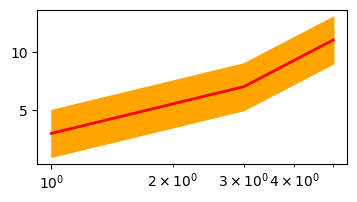

In [78]:
plt.figure(figsize=(4,2))
a = np.array([1,3,5])
b = np.array([3,7,11])
plt.semilogx(a,b, c='r', lw=2)
plt.fill_between(a, b-2, b+2, color='orange')
plt.show()

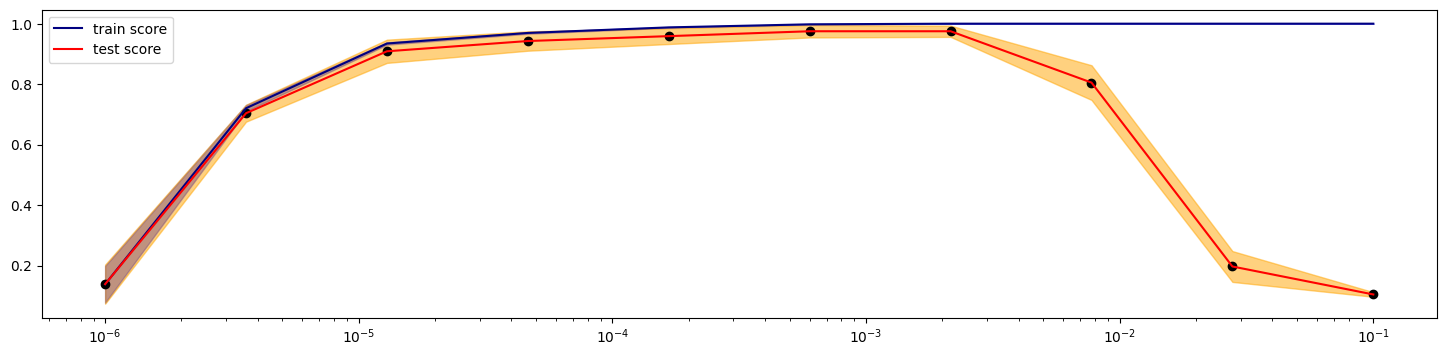

In [86]:
plt.figure(figsize=(18,4))
plt.semilogx(param_range, train_scores_mean, label='train score', color='navy')
plt.fill_between(param_range, 
                train_scores_mean- train_scores_std,
                train_scores_mean + train_scores_std,
                color='blue', alpha=0.5)
plt.semilogx(param_range, test_scores_mean, label= 'test score', color='red')
plt.fill_between(param_range, 
                test_scores_mean- test_scores_std,
                test_scores_mean + test_scores_std, 
                color='orange', alpha=0.5)
plt.scatter(param_range, test_scores_mean, c='k')
plt.legend(loc='best')
plt.show()

In [89]:
test_scores_mean.argmax() # 최적의 gamma 값이 있는 index

6

In [90]:
gamma = param_range[test_scores_mean.argmax()]
gamma

0.0021544346900318843

In [91]:
model = SVC(gamma=gamma).fit(X,y)
model.score(X,y)

1.0

## 2-2 GridSearchCV
- 복수 하이퍼 파라미터 최적화 클래스
- 모형 래퍼 성격 클래스 (가장 좋은 모형을 가지고 있음)
- fit(), predict(), score(), predict_proba(), decision_function() 메소드 가능 

In [93]:
import pandas as pd
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine_X, redwine_y =redwine.iloc[:, :-1], redwine.iloc[:, -1]
redwine_X.shape, redwine_y.shape

((1599, 11), (1599,))

In [100]:
%%time
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
selection = SelectKBest(k=1) # 가장 Anova f검정의 score가 높은 k개 변수를 찾음
svc       = SVC()
pipeline = Pipeline([('select', selection), 
                    ('svc', svc)])
# param_grid = {'select__k':[4,5,6,7,8,9,10,11], 
#              'svc__C':[0.1,1,10], # 값이 클수록 오차 허용이 엄격
#               'svc__gamma':[0.001, 0.002]
#              }

param_grid = dict(select__k =[4,5,6,7,8,9,10,11], 
                 svc__C =[0.1,1,10], 
                 svc__gamma =[0.001, 0.002])
grid_search = GridSearchCV(pipeline, 
                          param_grid=param_grid, #파라미터들
                          cv=2, # 2fold 교차검증
                          verbose=1, 
                           n_jobs=-1 # 모든 코어를 다씀 
                          )
grid_search.fit(redwine_X, redwine_y)

Fitting 2 folds for each of 48 candidates, totalling 96 fits
CPU times: total: 359 ms
Wall time: 3.62 s


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('select', SelectKBest(k=1)),
                                       ('svc', SVC())]),
             n_jobs=-1,
             param_grid={'select__k': [4, 5, 6, 7, 8, 9, 10, 11],
                         'svc__C': [0.1, 1, 10], 'svc__gamma': [0.001, 0.002]},
             verbose=1)

In [103]:
# 최적의 파라미터 값과 selectKBest의 k값 
print(grid_search.best_estimator_)

Pipeline(steps=[('select', SelectKBest(k=11)), ('svc', SVC(C=10, gamma=0.002))])


In [104]:
# 최적의 파라미터 값
print(grid_search.best_params_)

{'select__k': 11, 'svc__C': 10, 'svc__gamma': 0.002}


In [105]:
model = grid_search.best_estimator_
model.score(redwine_X, redwine_y)

0.6035021888680425

In [115]:
# 학습 데이터가 넘파이면 predict도 넘파이, 학습데이터가 데이터프레임이면 predict 도 데이터프레임으로 (경고출력X)
# x_data = redwine_X.iloc[0].values.reshape(1,-1)
x_data = pd.DataFrame(redwine_X.iloc[0]).T 
model.predict(x_data)

array([5], dtype=int64)

# 3절. 자료 불균형 처리
- 단순 언더/ 오버 샘플링
- 단순 오버 샘플링시 소수의 데이터를 단순 복사하면, 그 데이터에 의해 과적합 발생 가능
- SMOTE 오버 샘플링 

## 3-1 SMOTE를 이용한 오버샘플링 전

In [119]:
# 데이터
from sklearn.datasets import make_classification
X, y = make_classification(n_samples =10000, # 표본 데이터수
                           n_features= 10,  # 독립변수 수 
                           n_informative=5, # 종속변수와 상관관계가 잇는 독립변수 수
                           n_classes=2,     # 종속변수의 클래스 수 
                           n_clusters_per_class=1, #클래스 당 군의 수 
                           weights=[0.99, 0.01], # 각 클래스의 할당된 표본 비율 
                           random_state=42)
X.shape, y.shape

((10000, 10), (10000,))

In [120]:
import numpy as np 
np.unique(y, return_counts=True)

(array([0, 1]), array([9850,  150], dtype=int64))

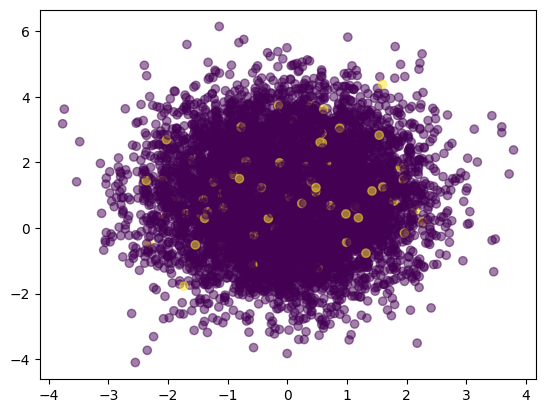

In [121]:
import matplotlib.pyplot as plt 
plt.scatter(x=X[:,0], y=X[:,1], c=y, alpha=0.5)

In [122]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                   test_size=0.3, 
                                                   stratify=y, #층화추출
                                                   random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7000, 10), (7000,), (3000, 10), (3000,))

In [125]:
print(np.unique(y, return_counts=True))
print(np.unique(y_train, return_counts= True))
print(np.unique(y_test, return_counts= True))

(array([0, 1]), array([9850,  150], dtype=int64))
(array([0, 1]), array([6895,  105], dtype=int64))
(array([0, 1]), array([2955,   45], dtype=int64))


In [128]:
y.mean(), y_train.mean(), y_test.mean()

(0.015, 0.015, 0.015)

In [130]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, #모델에서 사용할 트리 갯수
                                  max_features=2, # 각 노드에서 분할에 사용할 특징(열)의 최대수
                                  random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_features=2, random_state=42)

In [133]:
rf_pred = rf_model.predict(X_test)
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, rf_pred)

array([[2955,    0],
       [  35,   10]], dtype=int64)

In [134]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2955
           1       1.00      0.22      0.36        45

    accuracy                           0.99      3000
   macro avg       0.99      0.61      0.68      3000
weighted avg       0.99      0.99      0.98      3000



## 3-2 SMOTE를 이용한 오버 샘플링 후 
- pip install imbalanced-learn = 0.10.1

In [135]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7000, 10), (7000,), (3000, 10), (3000,))

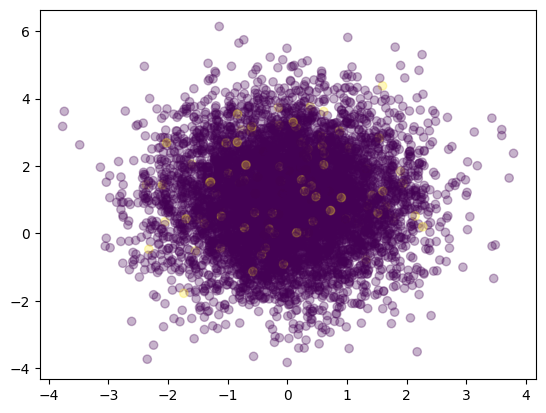

In [136]:
plt.scatter(x=X_train[:,0],y=X_train[:,1], c=y_train, alpha=0.3)
plt.show()

In [139]:
np.unique(y_train, return_counts=True)

(array([0, 1]), array([6895,  105], dtype=int64))

In [141]:
# SMOTE 오버 샘플링(X_train에만 적용)
from imblearn.over_sampling import SMOTE 
sm = SMOTE(
    #sampling_strategy={0:6895, 1:1050}
)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
X_resampled.shape, y_resampled.shape

((13790, 10), (13790,))

In [142]:
np.unique(y_resampled, return_counts=True)

(array([0, 1]), array([6895, 6895], dtype=int64))

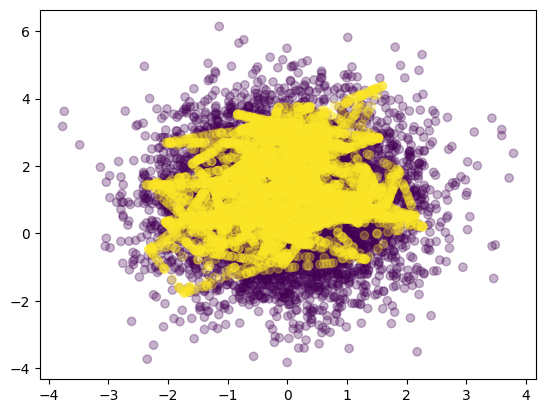

In [143]:
plt.scatter(x=X_resampled[:,0],y=X_resampled[:,1], c=y_resampled, alpha=0.3)
plt.show()

In [144]:
rf_model = RandomForestClassifier(n_estimators=100, 
                                 max_features=2, 
                                 random_state=42)
rf_model.fit(X_resampled, y_resampled)

RandomForestClassifier(max_features=2, random_state=42)

In [145]:
rf_pred = rf_model.predict(X_test)
confusion_matrix(y_test, rf_pred)

array([[2934,   21],
       [  26,   19]], dtype=int64)

In [146]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2955
           1       0.47      0.42      0.45        45

    accuracy                           0.98      3000
   macro avg       0.73      0.71      0.72      3000
weighted avg       0.98      0.98      0.98      3000



## 3-3 가중치 제어 
- 예측 모형에 class_weight 매개 변수 이용

In [147]:
rf_model = RandomForestClassifier(n_estimators=100, max_features=2, 
                                  class_weight={0:1, 1:2.5}, # y가 1인 데이터는 2.5배 더 중요하게
                                  random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 2.5}, max_features=2,
                       random_state=42)

In [148]:
rf_pred = rf_model.predict(X_test)
confusion_matrix(y_test, rf_pred)

array([[2955,    0],
       [  35,   10]], dtype=int64)

In [149]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2955
           1       1.00      0.22      0.36        45

    accuracy                           0.99      3000
   macro avg       0.99      0.61      0.68      3000
weighted avg       0.99      0.99      0.98      3000



# 4절. 최종 모형 탐색
- 앙상블 모형
    * 목적 : 여러분류 모델을 하나의 통합 분류모델로 연결하여 개별 분류 모델보다 더 좋은 일반화 성능을 달성
    * 방법
        + 여러 분류 알고리즘 사용 : 다수결 투표 (Voting) 
        + 하나의 분류 알고리즘을 여러 개  사용: 배깅(bagging; 데이터를 복원 추출하여 병렬) , 부스팅(boosting; 자료불균형일 경우 조금 더 잘 맞는 경향) 

### cf. 배깅 알고리즘 시 

In [153]:
np.random.choice(10, 10, replace=True) # 10개 데이터에서 복원 추출로 10개를 뽑음 

array([2, 0, 0, 1, 4])

In [160]:
N = 100000000 # 63.2% => 부트스트래핑과 0.632 규칙 
bootstrap = np.random.choice(N,N, replace=True)
print(len(set(bootstrap)),'개')
print(len(set(bootstrap))/N*100, '%')

63207787 개
63.207787 %


## 4-1 배깅 
- RandomForest

In [162]:
import pandas as pd 
wine_df = pd.read_csv('data/wine.csv')
wine_df.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,0D280/0D315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [165]:
wine_df['Class label'].value_counts()

2    71
1    59
3    48
Name: Class label, dtype: int64

In [166]:
X = wine_df.iloc[:, 1:]
y = wine_df.iloc[:,0]
X.shape, y.shape

((178, 13), (178,))

In [169]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y, 
                                                   test_size=0.3, 
                                                   stratify=y, 
                                                   random_state=1)


In [170]:
#의사 결정나무 알고리즘 
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(criterion='entropy')
tree.fit(train_X, train_y)
tree.score(test_X, test_y)

0.9259259259259259

In [177]:
%%time

# 배깅 알고리즘 

from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=tree, 
                       n_estimators=500,
                       bootstrap=True, # 복원 추출로 중복 추출 허용
                       oob_score=True, #중복 추출로 학습에 빠진 데이터를 score에 적용한 점수 볼 수 있음
                       random_state=1)
bag.fit(train_X, train_y)
bag.score(test_X, test_y)

CPU times: total: 1.59 s
Wall time: 1.6 s


0.9629629629629629

In [178]:
# 각 모델이 학습할때 뽑히지 않는 샘플을 이용하여 계산 성능 점수 
bag.oob_score_

0.9435483870967742

In [179]:
tf = RandomForestClassifier().fit(train_X, train_y)
tf.score(test_X, test_y)

1.0

## 4-2 임의의 데이터를 만들어 최적 모형 탐색 

In [180]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000, 
                          n_features=10, 
                          n_informative=5, 
                          n_classes=2, 
                          n_clusters_per_class=1, 
                          weights=[0.9, 0.1], 
                          random_state=42)
X.shape, y.shape,np.unique(y, return_counts=True)

((10000, 10), (10000,), (array([0, 1]), array([8963, 1037], dtype=int64)))

In [184]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, 
                                                   stratify=y, 
                                                   random_state=42)

# train 데이터의 오버샘플링 
sm = SMOTE()
resampled_X, resampled_y = sm.fit_resample(train_X, train_y)
resampled_X.shape, resampled_y.shape, np.unique(resampled_y, return_counts=True)

((14340, 10), (14340,), (array([0, 1]), array([7170, 7170], dtype=int64)))

In [191]:
from sklearn.metrics import precision_score, recall_score, f1_score
def model_measure(model, train_X=resampled_X, train_y = resampled_y, test_X=test_X, test_y=test_y):
    '모델을 학습 한 후 모델의 정확도 정밀도 재현율 f1점수를 return'
    model.fit(train_X, train_y)  # 학습
    pred = model.predict(test_X) #예측값
    accuracy = model.score(test_X, test_y)
    precision = precision_score(test_y, pred)
    recall  = recall_score(test_y, pred)
    f1score = f1_score(test_y, pred)
    return '정확도:{:.3f}, 정밀도:{:.3f},재현율:{:.3f}, fq score:{:.3f}'.format(accuracy, 
                                                                      precision, 
                                                                      recall, 
                                                                      f1score)

In [192]:
rf_model = RandomForestClassifier(n_estimators=100, max_features=2, random_state=42)
model_measure(rf_model)

'정확도:0.981, 정밀도:0.924,재현율:0.884, fq score:0.904'

In [194]:
from sklearn.svm import SVC 
svc_model = SVC(random_state=42)
model_measure(svc_model)

'정확도:0.987, 정밀도:0.955,재현율:0.918, fq score:0.936'

In [195]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500)
model_measure(mlp_model)

'정확도:0.986, 정밀도:0.945,재현율:0.913, fq score:0.929'

## 4-3 부스팅(AdaBoost, XGB, LGBM, CatB)
- 알고리즘들을 순차적으로 학습하면서 이전 학습한 알고리즘 예측이 틀린 데이터를 올바르게 예측할 수 있도록 가중치 부여

In [196]:
from sklearn.ensemble import AdaBoostClassifier
model_measure(AdaBoostClassifier())

'정확도:0.950, 정밀도:0.704,재현율:0.884, fq score:0.784'

In [198]:
from xgboost import XGBClassifier
model_measure(XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.01))

'정확도:0.972, 정밀도:0.844,재현율:0.889, fq score:0.866'

In [201]:
from lightgbm import LGBMClassifier
# 행기준으로 각 피처를 빠르게 탐색
model_measure(LGBMClassifier(n_estimators=100, verbose=0))

'정확도:0.983, 정밀도:0.918,재현율:0.918, fq score:0.918'

In [204]:
from catboost import CatBoostClassifier
model_measure(CatBoostClassifier(verbose=0))

'정확도:0.987, 정밀도:0.959,재현율:0.908, fq score:0.933'

## 4-4 투표를 이용한 앙상블
- voting='hard': 다수결로 투표
- voting='soft': 확률이 합을 계산하여 투표 

In [215]:
rf_model = RandomForestClassifier(n_estimators=100, max_features=2, random_state=42)
xgb_model = XGBClassifier(max_depth=10, 
                         n_estimators=100, # 이진 분류에서의 평가 지표 
                        ) 
lgb_model = LGBMClassifier(n_estimators=100, verbose=0)
svc_model = SVC(probability=True, random_state=42)
print(model_measure(rf_model))
print(model_measure(xgb_model))
print(model_measure(lgb_model))

정확도:0.981, 정밀도:0.924,재현율:0.884, fq score:0.904
정확도:0.983, 정밀도:0.922,재현율:0.913, fq score:0.917
정확도:0.983, 정밀도:0.918,재현율:0.918, fq score:0.918


In [216]:
%%time 
from sklearn.ensemble import VotingClassifier
voting_model = VotingClassifier(estimators=[('rmf', rf_model), 
                                           ('lgb', lgb_model), 
                                           ('svc', svc_model)], 
                                            voting='hard')
voting_model.fit(resampled_X, resampled_y)

CPU times: total: 14 s
Wall time: 11.7 s


VotingClassifier(estimators=[('rmf',
                              RandomForestClassifier(max_features=2,
                                                     random_state=42)),
                             ('lgb', LGBMClassifier(verbose=0)),
                             ('svc', SVC(probability=True, random_state=42))])

In [210]:
print(model_measure(voting_model))

정확도:0.984, 정밀도:0.935,재현율:0.908, fq score:0.922


In [212]:
# 개별 모델 
voting_model.named_estimators_

{'rmf': RandomForestClassifier(max_features=2, random_state=42),
 'lgb': LGBMClassifier(verbose=0),
 'svc': SVC()}

In [218]:
voting_model = VotingClassifier(estimators=[('rmf', rf_model), 
                                           ('lgb', lgb_model), 
                                           ('svc', svc_model)], 
                                            voting='soft')
model_measure(voting_model)

'정확도:0.985, 정밀도:0.932,재현율:0.923, fq score:0.927'